### Objective:

Develop a model to predict cost vs. number of units sold using polynomial regression
- Independence variable X: number of units produced
- Dependence variable Y: cost of good sold

In [168]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

### Data Understanding

In [169]:
cost_df = pd.read_csv("data/EconomiesOfScale.csv")

In [170]:
cost_df.head()

,Number of Units,Manufacturing Cost
0,1.000000,95.066056
1,1.185994,96.531750
2,1.191499,73.661311
3,1.204771,95.566843
4,1.298773,98.777013


In [171]:
cost_df.tail()

,Number of Units,Manufacturing Cost
995,8.099710,23.855067
996,8.739752,27.536542
997,8.780888,25.973787
998,8.897700,25.138311
999,10.000000,21.547777


In [172]:
cost_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Number of Units     1000 non-null   float64
 1   Manufacturing Cost  1000 non-null   float64
dtypes: float64(2)
memory usage: 15.8 KB


In [173]:
cost_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Number of Units,1000.0,4.472799,1.336241,1.0,3.594214,4.435958,5.324780,10.0
Manufacturing Cost,1000.0,40.052999,10.595322,20.0,32.912036,38.345781,44.531822,100.0


In [174]:
display(cost_df.shape)
display(cost_df.columns)

(1000, 2)

Index(['Number of Units', 'Manufacturing Cost'], dtype='str')

In [175]:
cost_df.isnull().sum()

Number of Units       0
Manufacturing Cost    0
dtype: int64

In [176]:
cost_df.duplicated().sum()

np.int64(0)

### Visualize Dataset

<Figure size 800x600 with 0 Axes>

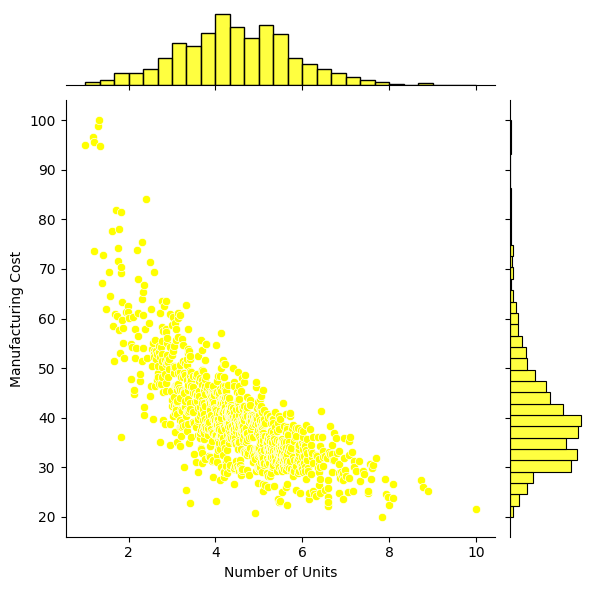

In [177]:
plt.figure(figsize=(8,6))
sns.jointplot(x='Number of Units', y='Manufacturing Cost', data=cost_df, color='yellow')
plt.show()

<Figure size 800x600 with 0 Axes>

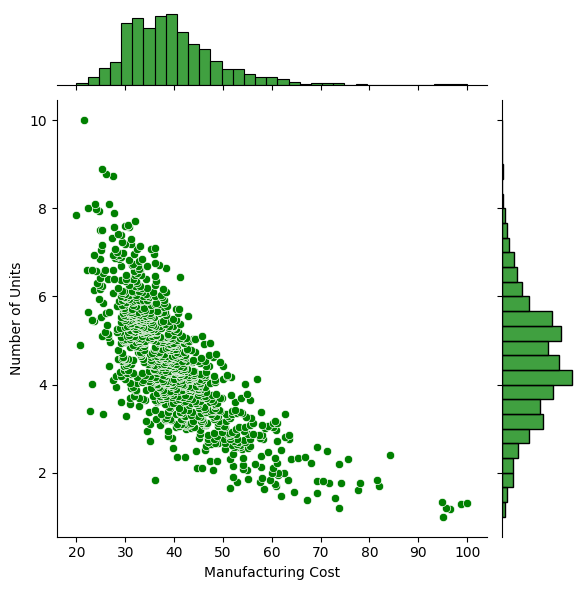

In [178]:
plt.figure(figsize=(8,6))
sns.jointplot(x='Manufacturing Cost', y='Number of Units', data=cost_df, color='green')
plt.show()

<Figure size 800x600 with 0 Axes>

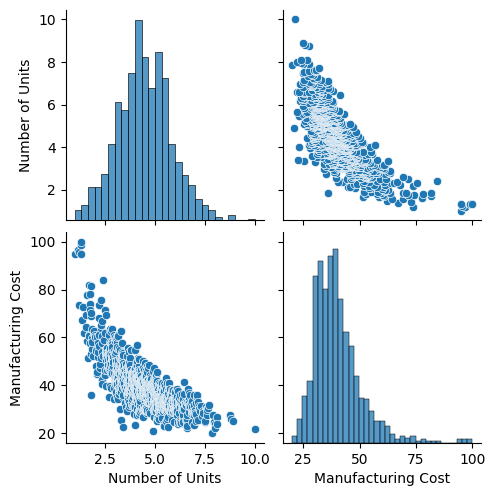

In [179]:
plt.figure(figsize=(8,6))
sns.pairplot(data=cost_df)
plt.show()

<Figure size 800x600 with 0 Axes>

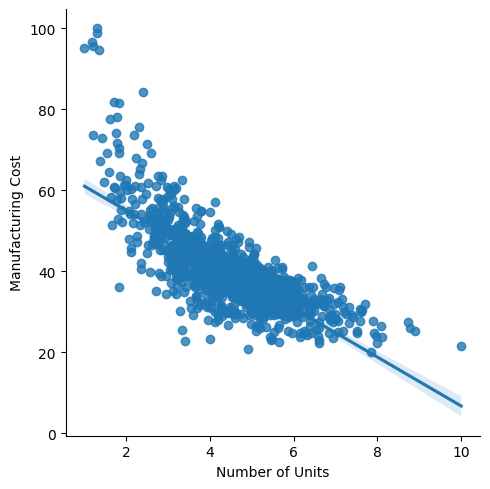

In [180]:
plt.figure(figsize=(8,6))
sns.lmplot(x='Number of Units', y='Manufacturing Cost', data=cost_df)
plt.show()

<Figure size 800x600 with 0 Axes>

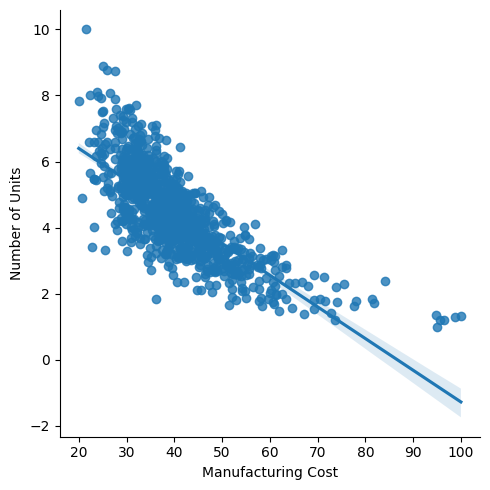

In [181]:
plt.figure(figsize=(8,6))
sns.lmplot(x='Manufacturing Cost', y='Number of Units', data=cost_df)
plt.show()

### Create Train and Test Set

In [182]:
from sklearn.model_selection import train_test_split

In [183]:
X = cost_df[['Number of Units']]
y = cost_df['Manufacturing Cost']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=14)

In [184]:
X_train.head()

,Number of Units
961,6.942155
554,4.614245
226,3.426723
415,4.193284
778,5.462203


In [185]:
y_train.head()

961    23.531414
554    29.343600
226    49.204026
415    34.971997
778    31.081923
Name: Manufacturing Cost, dtype: float64

In [186]:
display(X_train.shape)
display(y_train.shape)
display(X_test.shape)
display(y_test.shape)

(800, 1)

(800,)

(200, 1)

(200,)

### Train the Models

#### Linear Assumption

In [187]:
from sklearn.linear_model import LinearRegression

In [188]:
lr = LinearRegression(fit_intercept=True)
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [189]:
print('Linear Model coeff (m):', lr.coef_)
print('Linear Model coeff (b):', lr.intercept_)

Linear Model coeff (m): [-6.09642146]
Linear Model coeff (b): 67.06847408480157


In [190]:
lr2 = LinearRegression(fit_intercept=False)
lr2.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",False
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [191]:
print('Linear Model coeff (m):', lr2.coef_)
print('Linear Model coeff (b):', lr2.intercept_)

Linear Model coeff (m): [7.75832789]
Linear Model coeff (b): 0.0


In [192]:
y_pred_lr = lr.predict(X_train)
y_pred_lr2 = lr2.predict(X_train)

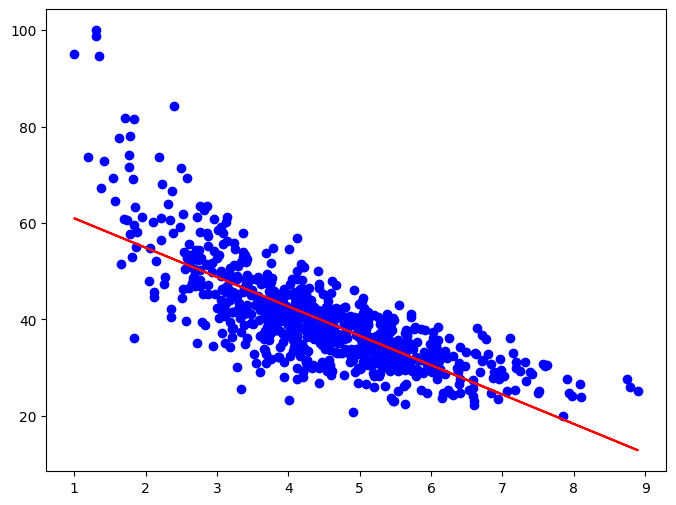

In [193]:
plt.figure(figsize=(8,6))
plt.scatter(X_train, y_train, color='blue')
plt.plot(X_train, y_pred_lr, color='red')

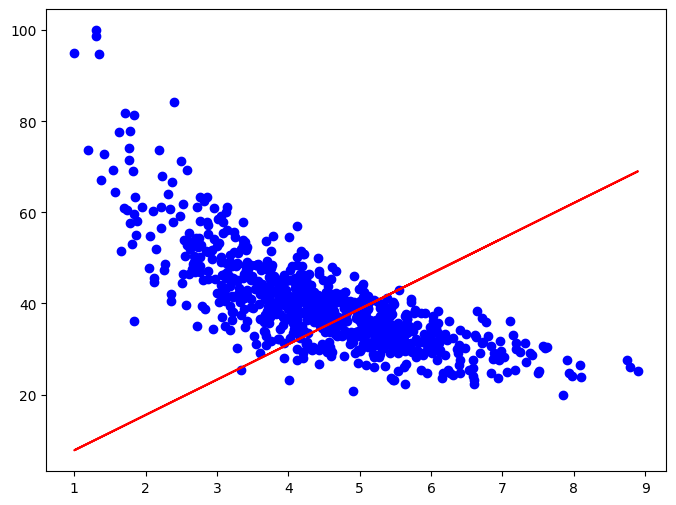

In [194]:
plt.figure(figsize=(8,6))
plt.scatter(X_train, y_train, color='blue')
plt.plot(X_train, y_pred_lr2, color='red')

#### Polynomial Assumption

In [195]:
from sklearn.preprocessing import PolynomialFeatures

In [196]:
pl2 = PolynomialFeatures(degree=2)
X_columns2 = pl2.fit_transform(X_train)

In [197]:
X_columns2

array([[ 1.        ,  6.9421551 , 48.19351742],
       [ 1.        ,  4.61424513, 21.29125808],
       [ 1.        ,  3.42672332, 11.74243273],
       ...,
       [ 1.        ,  3.66818642, 13.45559163],
       [ 1.        ,  3.96594464, 15.7287169 ],
       [ 1.        ,  4.89276673, 23.93916624]], shape=(800, 3))

In [198]:
poly2 = LinearRegression()
poly2.fit(X_columns2, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [199]:
print('Model Coeff:', poly2.coef_)

Model Coeff: [  0.         -16.98712363   1.18968366]


In [200]:
pl3 = PolynomialFeatures(degree=3)
X_columns3 = pl3.fit_transform(X_train)

In [201]:
X_columns3

array([[  1.        ,   6.9421551 ,  48.19351742, 334.56687269],
       [  1.        ,   4.61424513,  21.29125808,  98.24308384],
       [  1.        ,   3.42672332,  11.74243273,  40.23806811],
       ...,
       [  1.        ,   3.66818642,  13.45559163,  49.3576185 ],
       [  1.        ,   3.96594464,  15.7287169 ,  62.37922053],
       [  1.        ,   4.89276673,  23.93916624, 117.12875607]],
      shape=(800, 4))

In [202]:
poly3 = LinearRegression()
poly3.fit(X_columns3, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [203]:
print('Model Coeff:', poly3.coef_)

Model Coeff: [  0.         -33.52825681   4.99144307  -0.26761002]


In [204]:
pl4 = PolynomialFeatures(degree=4)
X_columns4 = pl4.fit_transform(X_train)

In [205]:
X_columns4

array([[1.00000000e+00, 6.94215510e+00, 4.81935174e+01, 3.34566873e+02,
        2.32261512e+03],
       [1.00000000e+00, 4.61424513e+00, 2.12912581e+01, 9.82430838e+01,
        4.53317671e+02],
       [1.00000000e+00, 3.42672332e+00, 1.17424327e+01, 4.02380681e+01,
        1.37884726e+02],
       ...,
       [1.00000000e+00, 3.66818642e+00, 1.34555916e+01, 4.93576185e+01,
        1.81052946e+02],
       [1.00000000e+00, 3.96594464e+00, 1.57287169e+01, 6.23792205e+01,
        2.47392535e+02],
       [1.00000000e+00, 4.89276673e+00, 2.39391662e+01, 1.17128756e+02,
        5.73083680e+02]], shape=(800, 5))

In [206]:
poly4 = LinearRegression()
poly4.fit(X_columns4, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [207]:
print('Model Coeff:', poly4.coef_)

Model Coeff: [  0.         -61.70891793  15.27117424  -1.79395747   0.07892893]


In [208]:
pl5 = PolynomialFeatures(degree=5)
X_columns5 = pl5.fit_transform(X_train)

In [209]:
X_columns5

array([[1.00000000e+00, 6.94215510e+00, 4.81935174e+01, 3.34566873e+02,
        2.32261512e+03, 1.61239544e+04],
       [1.00000000e+00, 4.61424513e+00, 2.12912581e+01, 9.82430838e+01,
        4.53317671e+02, 2.09171885e+03],
       [1.00000000e+00, 3.42672332e+00, 1.17424327e+01, 4.02380681e+01,
        1.37884726e+02, 4.72492808e+02],
       ...,
       [1.00000000e+00, 3.66818642e+00, 1.34555916e+01, 4.93576185e+01,
        1.81052946e+02, 6.64135958e+02],
       [1.00000000e+00, 3.96594464e+00, 1.57287169e+01, 6.23792205e+01,
        2.47392535e+02, 9.81145100e+02],
       [1.00000000e+00, 4.89276673e+00, 2.39391662e+01, 1.17128756e+02,
        5.73083680e+02, 2.80396476e+03]], shape=(800, 6))

In [210]:
poly5 = LinearRegression()
poly5.fit(X_columns5, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [211]:
print('Model Coeff:', poly5.coef_)

Model Coeff: [ 0.00000000e+00 -1.02172343e+02  3.58169126e+01 -6.58193504e+00
  5.98234397e-01 -2.11840063e-02]


In [212]:
pl10 = PolynomialFeatures(degree=10)
X_columns10 = pl10.fit_transform(X_train)

In [213]:
X_columns10[0]

array([1.00000000e+00, 6.94215510e+00, 4.81935174e+01, 3.34566873e+02,
       2.32261512e+03, 1.61239544e+04, 1.11934992e+05, 7.77070078e+05,
       5.39454100e+06, 3.74497403e+07, 2.59981906e+08])

In [214]:
poly10 = LinearRegression()
poly10.fit(X_columns10, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [215]:
print('Model Coeff:', poly10.coef_)

Model Coeff: [ 0.00000000e+00  2.62886185e+03 -3.75508036e+03  2.88062568e+03
 -1.34754435e+03  4.06505418e+02 -8.07335073e+01  1.04883839e+01
 -8.57363373e-01  3.99920667e-02 -8.11319407e-04]


In [216]:
y_pred_poly2 = poly2.predict(X_columns2)
y_pred_poly3 = poly3.predict(X_columns3)
y_pred_poly4 = poly4.predict(X_columns4)
y_pred_poly5 = poly5.predict(X_columns5)
y_pred_poly10 = poly10.predict(X_columns10)

In [217]:
def plot_polynomial(X_train, y_train, y_pred):
    if isinstance(X_train, (pd.DataFrame, pd.Series)):
        X_train_np = X_train.to_numpy().flatten()
    else:
        X_train_np = X_train.flatten()
    
    sorted_indices = np.argsort(X_train_np)
    sorted_X_train = X_train_np[sorted_indices]
    sorted_y_pred = y_pred[sorted_indices]
    
    plt.figure(figsize=(8, 6))
    plt.scatter(X_train_np, y_train, color='gray')
    plt.plot(sorted_X_train, sorted_y_pred, color='blue')
    plt.show()

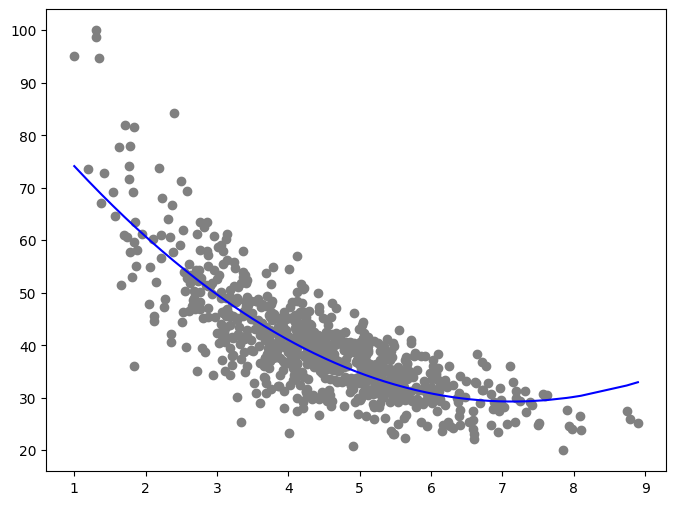

In [218]:
plot_polynomial(X_train, y_train, y_pred_poly2)

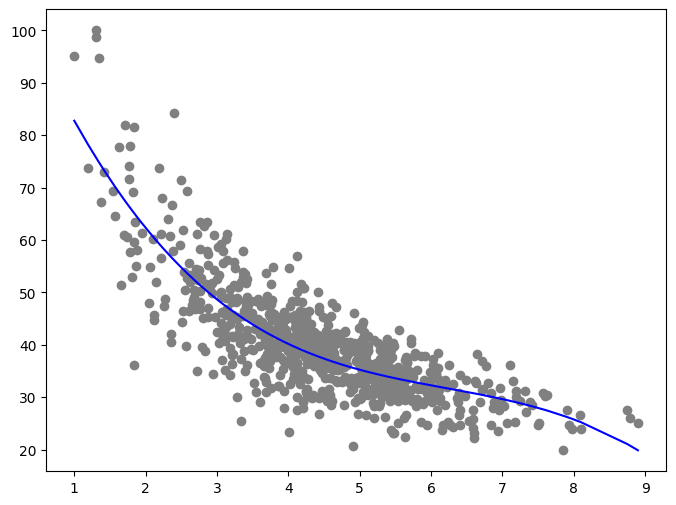

In [219]:
plot_polynomial(X_train, y_train, y_pred_poly3)

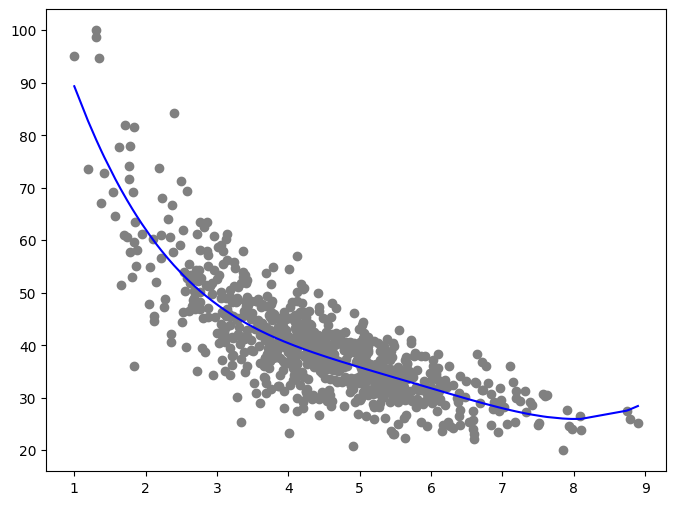

In [220]:
plot_polynomial(X_train, y_train, y_pred_poly4)

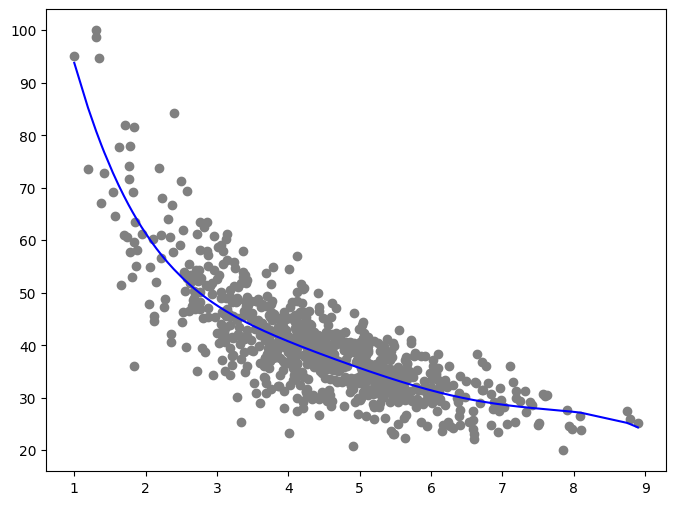

In [221]:
plot_polynomial(X_train, y_train, y_pred_poly5)

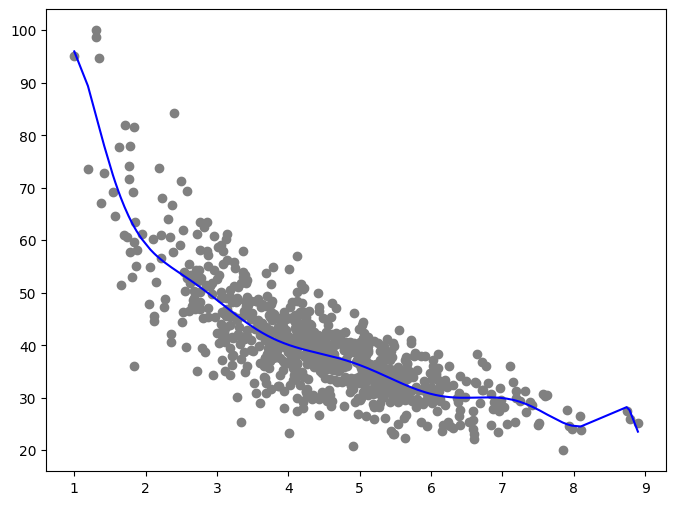

In [222]:
plot_polynomial(X_train, y_train, y_pred_poly10)

### Apply Models in Test Set

In [223]:
y_pred_test_lr = lr.predict(X_test)
y_pred_test_lr2 = lr2.predict(X_test)

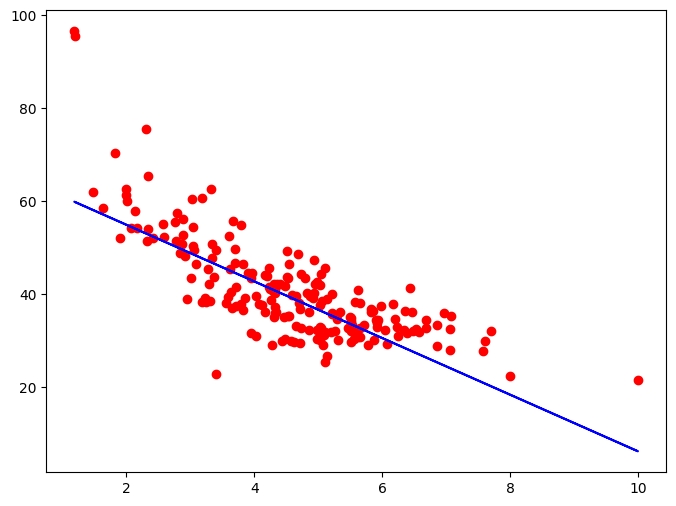

In [224]:
plt.figure(figsize=(8,6))
plt.scatter(X_test, y_test, color='red')
plt.plot(X_test, y_pred_test_lr, color='blue')

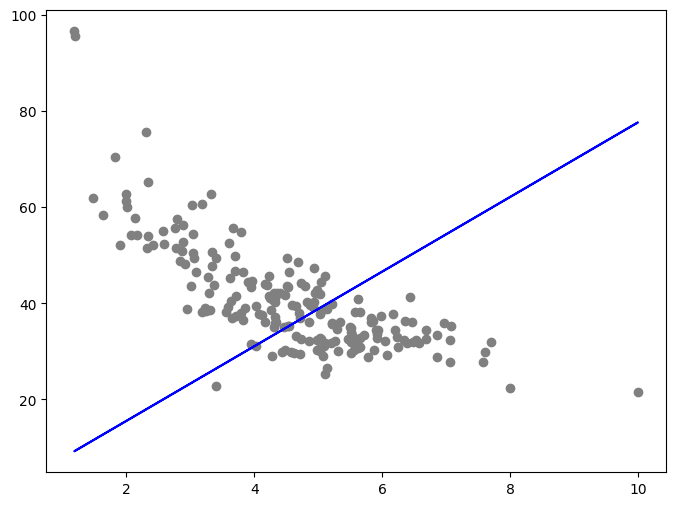

In [225]:
plt.figure(figsize=(8,6))
plt.scatter(X_test, y_test, color='gray')
plt.plot(X_test, y_pred_test_lr2, color='blue')

In [226]:
y_pred_test_poly2 = poly2.predict(pl2.transform(X_test))
y_pred_test_poly3 = poly3.predict(pl3.transform(X_test))
y_pred_test_poly4 = poly4.predict(pl4.transform(X_test))
y_pred_test_poly5 = poly5.predict(pl5.transform(X_test))
y_pred_test_poly10 = poly10.predict(pl10.transform(X_test))

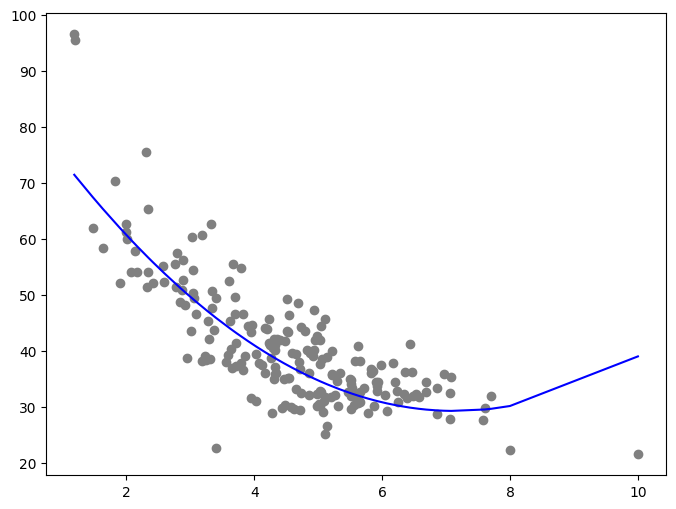

In [227]:
plot_polynomial(X_test, y_test, y_pred_test_poly2)

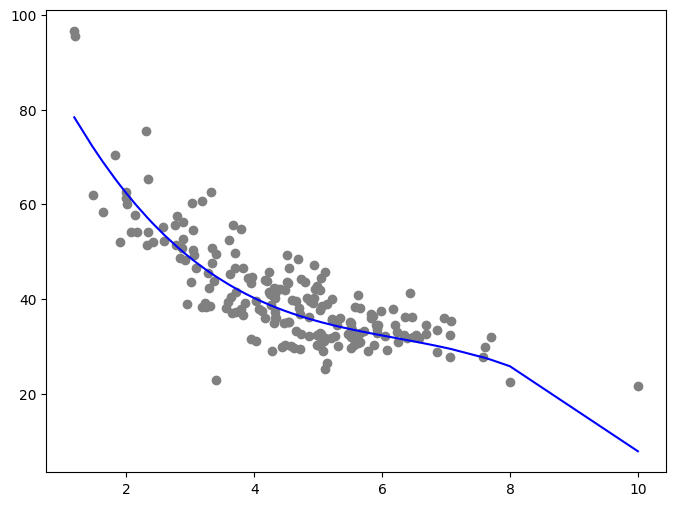

In [228]:
plot_polynomial(X_test, y_test, y_pred_test_poly3)

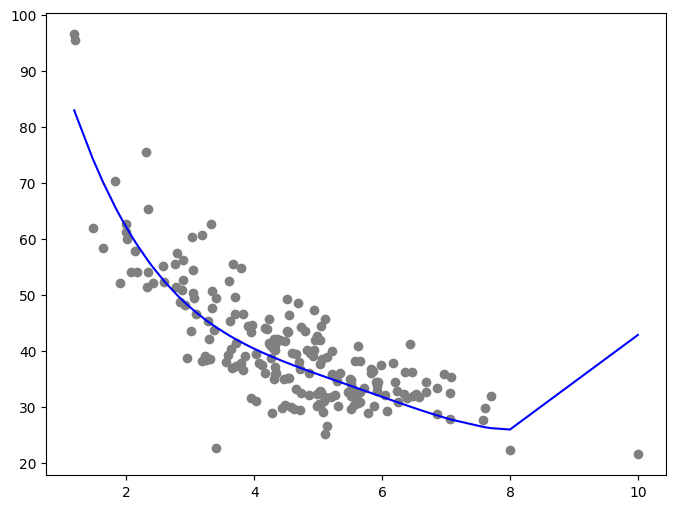

In [229]:
plot_polynomial(X_test, y_test, y_pred_test_poly4)

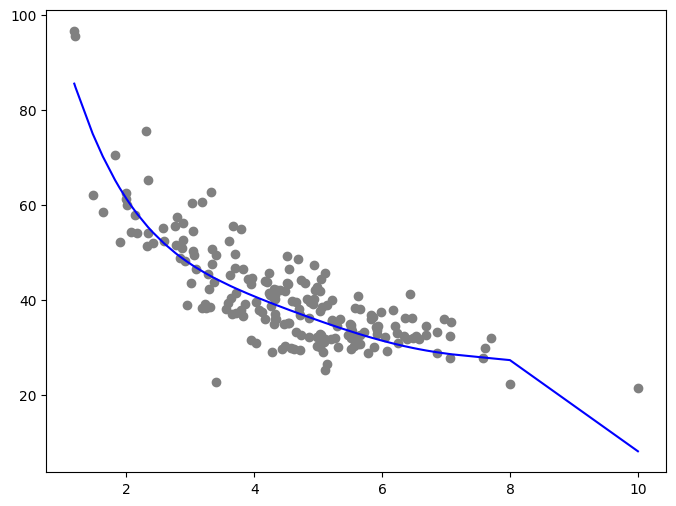

In [230]:
plot_polynomial(X_test, y_test, y_pred_test_poly5)

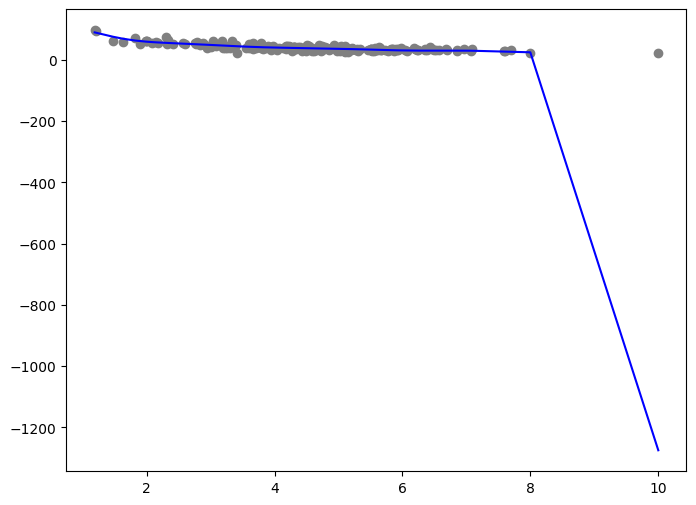

In [231]:
plot_polynomial(X_test, y_test, y_pred_test_poly10)

### Model Evaluation

In [234]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

#### Training Set Evaluation

In [236]:
def evaluate_model(y_true, y_pred, X_train, model_name):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    n = len(y_true)
    p = X_train.shape[1]
    adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
    
    metrics_df = pd.DataFrame({
        'R-squared': [r2],
        'Mean Absolute Error': [mae],
        'Mean Squared Error': [mse],
        'Root Mean Squared Error': [rmse],
        'Mean Absolute Percentage Error': [mape],
        'Adjusted R-squared': [adjusted_r2]
    }, index=[model_name])
    
    formatted_metrics_df = metrics_df.style.format("{:.6f}").highlight_max(axis=0, color="green")
    return formatted_metrics_df

In [237]:
display(evaluate_model(y_train, y_pred_lr, X_train, 'Linear Regression'))
display(evaluate_model(y_train, y_pred_lr2, X_train, 'Linear Regression (no intercept)'))
display(evaluate_model(y_train, y_pred_poly2, X_train, 'Polynomial Regression (2-Degree)'))
display(evaluate_model(y_train, y_pred_poly3, X_train, 'Polynomial Regression (3-Degree)'))
display(evaluate_model(y_train, y_pred_poly4, X_train, 'Polynomial Regression (4-Degree)'))
display(evaluate_model(y_train, y_pred_poly5, X_train, 'Polynomial Regression (5-Degree)'))
display(evaluate_model(y_train, y_pred_poly10, X_train, 'Polynomial Regression (10-Degree)'))

,R-squared,Mean Absolute Error,Mean Squared Error,Root Mean Squared Error,Mean Absolute Percentage Error,Adjusted R-squared
Linear Regression,0.582330,4.843131,45.916127,6.776144,0.124704,0.581806


,R-squared,Mean Absolute Error,Mean Squared Error,Root Mean Squared Error,Mean Absolute Percentage Error,Adjusted R-squared
Linear Regression (no intercept),-2.686367,15.039333,405.256742,20.130990,0.366613,-2.690986


,R-squared,Mean Absolute Error,Mean Squared Error,Root Mean Squared Error,Mean Absolute Percentage Error,Adjusted R-squared
Polynomial Regression (2-Degree),0.663272,4.494356,37.017812,6.084227,0.115279,0.662850


,R-squared,Mean Absolute Error,Mean Squared Error,Root Mean Squared Error,Mean Absolute Percentage Error,Adjusted R-squared
Polynomial Regression (3-Degree),0.681604,4.451638,35.002560,5.916296,0.114377,0.681205


,R-squared,Mean Absolute Error,Mean Squared Error,Root Mean Squared Error,Mean Absolute Percentage Error,Adjusted R-squared
Polynomial Regression (4-Degree),0.688480,4.401367,34.246562,5.852056,0.112861,0.688090


,R-squared,Mean Absolute Error,Mean Squared Error,Root Mean Squared Error,Mean Absolute Percentage Error,Adjusted R-squared
Polynomial Regression (5-Degree),0.690547,4.377778,34.019405,5.832616,0.112275,0.690159


,R-squared,Mean Absolute Error,Mean Squared Error,Root Mean Squared Error,Mean Absolute Percentage Error,Adjusted R-squared
Polynomial Regression (10-Degree),0.695632,4.351918,33.460352,5.784492,0.111631,0.695251


#### Test Set Evaluation

In [238]:
display(evaluate_model(y_test, y_pred_test_lr, X_test, 'Linear Regression'))
display(evaluate_model(y_test, y_pred_test_lr2, X_test, 'Linear Regression (no intercept)'))
display(evaluate_model(y_test, y_pred_test_poly2, X_test, 'Polynomial Regression (2-Degree)'))
display(evaluate_model(y_test, y_pred_test_poly3, X_test, 'Polynomial Regression (3-Degree)'))
display(evaluate_model(y_test, y_pred_test_poly4, X_test, 'Polynomial Regression (4-Degree)'))
display(evaluate_model(y_test, y_pred_test_poly5, X_test, 'Polynomial Regression (5-Degree)'))
display(evaluate_model(y_test, y_pred_test_poly10, X_test, 'Polynomial Regression (10-Degree)'))

,R-squared,Mean Absolute Error,Mean Squared Error,Root Mean Squared Error,Mean Absolute Percentage Error,Adjusted R-squared
Linear Regression,0.562472,5.252613,52.775758,7.264693,0.133988,0.560262


,R-squared,Mean Absolute Error,Mean Squared Error,Root Mean Squared Error,Mean Absolute Percentage Error,Adjusted R-squared
Linear Regression (no intercept),-2.769636,15.824641,454.702965,21.323765,0.371463,-2.788674


,R-squared,Mean Absolute Error,Mean Squared Error,Root Mean Squared Error,Mean Absolute Percentage Error,Adjusted R-squared
Polynomial Regression (2-Degree),0.668851,4.773465,39.944010,6.320127,0.119982,0.667179


,R-squared,Mean Absolute Error,Mean Squared Error,Root Mean Squared Error,Mean Absolute Percentage Error,Adjusted R-squared
Polynomial Regression (3-Degree),0.702920,4.588636,35.834553,5.986197,0.114392,0.701419


,R-squared,Mean Absolute Error,Mean Squared Error,Root Mean Squared Error,Mean Absolute Percentage Error,Adjusted R-squared
Polynomial Regression (4-Degree),0.691703,4.693704,37.187503,6.098156,0.119168,0.690146


,R-squared,Mean Absolute Error,Mean Squared Error,Root Mean Squared Error,Mean Absolute Percentage Error,Adjusted R-squared
Polynomial Regression (5-Degree),0.707428,4.614440,35.290810,5.940607,0.116691,0.705950


,R-squared,Mean Absolute Error,Mean Squared Error,Root Mean Squared Error,Mean Absolute Percentage Error,Adjusted R-squared
Polynomial Regression (10-Degree),-68.933387,10.962735,8435.541651,91.845205,0.413587,-69.286586
